
# 🎓 Student Performance Prediction Assignment
Applied AI & Machine Learning (CS-333)  
Instructor: Dr. Abbas Hussain  

---

## Objective
Predict **Performance Index** using multiple ML regression models.


## Import Libraries

In [196]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
%matplotlib inline
sns.set(color_codes=True)



## Load Dataset

In [197]:
# Load dataset
url = "https://raw.githubusercontent.com/AbbasHussain72/PNEC-CS-333-Applied-AI-ML/main/labs/Lab-03_LR_SVC/Student_Performance.csv"
df = pd.read_csv(url)
df.head()


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


## Exploratory Data Analysis

In [198]:
# Check Type and info
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [199]:
# Check missing values
print(df.isnull().sum())


Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


In [200]:
df.shape

(10000, 6)

In [201]:
# Check Duplicate values
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)


number of duplicate rows:  (127, 6)


In [202]:
# Dropping the duplicate values

df = df.drop_duplicates()
df.head(5)



,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [203]:
df.count()

,0
Hours Studied,9873
Previous Scores,9873
Extracurricular Activities,9873
Sleep Hours,9873
Sample Question Papers Practiced,9873
Performance Index,9873


In [204]:
# Renaming the columns for ease

df.rename(columns = {'Extracurricular Activities':'Extra Activity', 'Performance Index':'PI', 'Sample Question Papers Practiced':'Practice Qs'}, inplace = True)

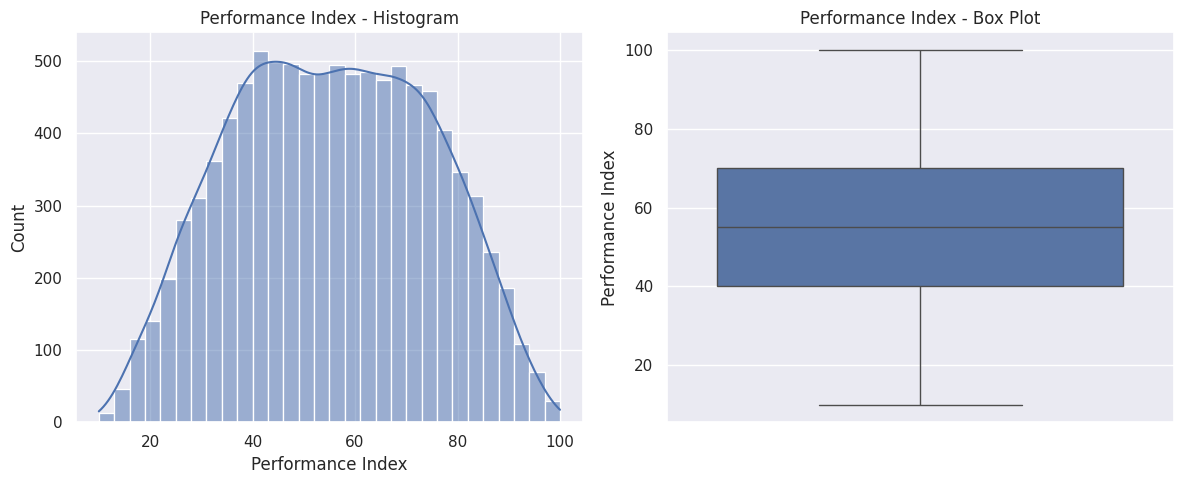

Performance Index Skewness: -0.00
Performance Index Kurotsis: -0.86


In [205]:
# Distibution Plot

# Visualizing the Performance Index.

plt.figure(figsize=(12, 5)) #Setting the figure size.

# Left: Histogram
plt.subplot(1, 2, 1)
sns.histplot(df["PI"], kde=True, bins=30)
plt.title("Performance Index - Histogram")
plt.xlabel("Performance Index", fontsize=12)

# Right: Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(y=df["PI"])
plt.title("Performance Index - Box Plot")
plt.ylabel("Performance Index", fontsize=12)

plt.tight_layout()
plt.show()

# Calculating skewness and kurtosis of the Performance Index.
skewness = df["PI"].skew()
kurtosis = df["PI"].kurt()
print(f"Performance Index Skewness: {skewness:.2f}")
print(f"Performance Index Kurotsis: {kurtosis:.2f}")

## Encoding (if needed)

In [206]:
# Encode categorical columns if any

from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    "Extra Activity"
]
df_encoded = df.copy()
le = LabelEncoder()

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])




In [207]:
df1 = df_encoded.copy()
df1.head()

,Hours Studied,Previous Scores,Extra Activity,Sleep Hours,Practice Qs,PI
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


## Visualization

In [208]:
# Scatter plots
# Heatmap



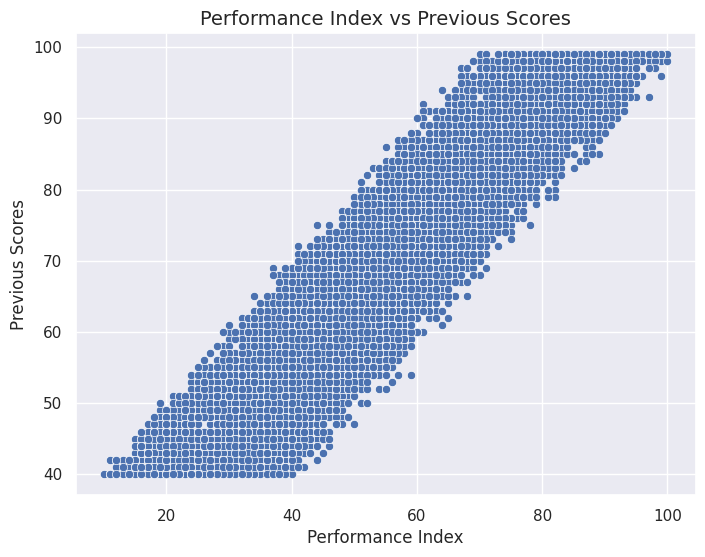

In [209]:
# Examining the relationship between Performance Index and Previous Scores.

# Creating a scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(x="PI", y="Previous Scores", data=df1)
plt.title(f"Performance Index vs Previous Scores", fontsize=14)
plt.xlabel("Performance Index", fontsize=12)
plt.ylabel("Previous Scores", fontsize=12)
# plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Correlation Analysis

<Axes: >

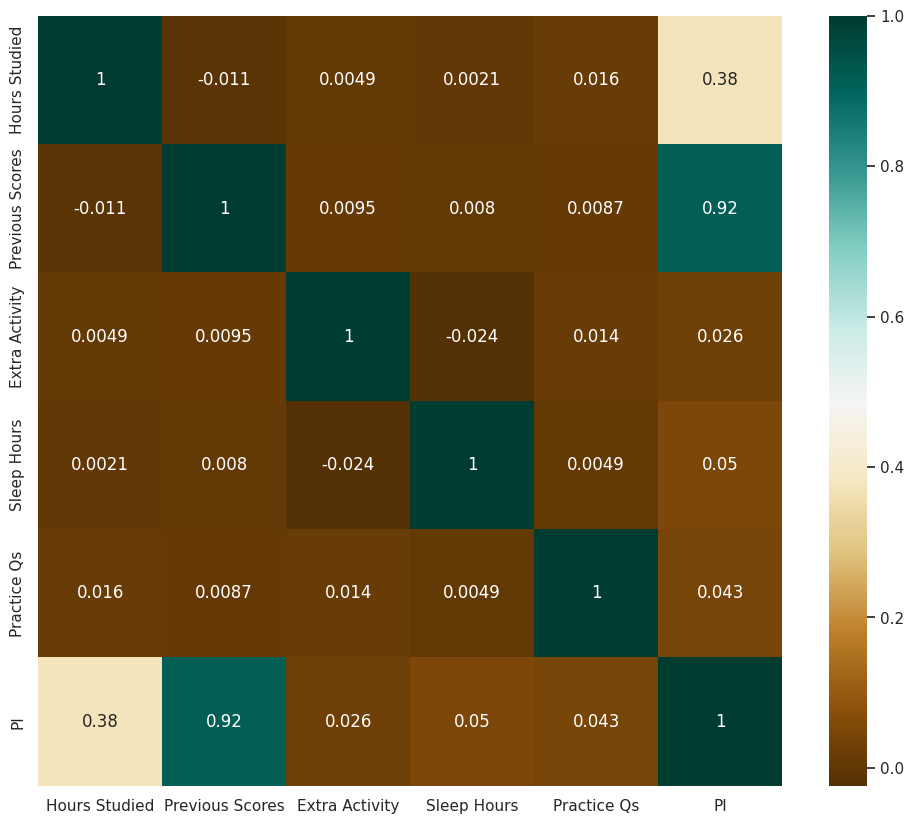

In [210]:
# Compute correlation matrix
c = df1.corr()
plt.figure(figsize=(12,10))
sns.heatmap(c,cmap="BrBG",annot=True)

## Feature Selection
From the correlation matrix, we can observe the correlation of each feature with the 'PI' (Performance Index). We can set a threshold to select features that have a strong correlation (either positive or negative) with the target variable.

In [211]:
# Get correlations with the target variable 'PI'

correlations = df1.corr()['PI'].sort_values(ascending=False)
print("Correlations with Performance Index (PI):\n", correlations)


selected_features_corr = correlations[abs(correlations) > 0.5].index.tolist()

if 'PI' in selected_features_corr:
    selected_features_corr.remove('PI')

print(f"\nFeatures selected based on correlation (> 0.5): {selected_features_corr}")


X_corr_selected = df1[selected_features_corr]
y_target = df1['PI']

print("\nShape of X_corr_selected:", X_corr_selected.shape)
print("Features in X_corr_selected:", X_corr_selected.columns.tolist())


Correlations with Performance Index (PI):
 PI                 1.000000
Previous Scores    0.915135
Hours Studied      0.375332
Sleep Hours        0.050352
Practice Qs        0.043436
Extra Activity     0.026075
Name: PI, dtype: float64

Features selected based on correlation (> 0.5): ['Previous Scores']

Shape of X_corr_selected: (9873, 1)
Features in X_corr_selected: ['Previous Scores']


## Train-Test Split

In [212]:
from sklearn.model_selection import train_test_split # For splitting the dataset.
from sklearn.preprocessing import MinMaxScaler # For Scaling the features.

X = df1.drop("PI", axis=1)
y = df1["PI"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=56)



In [213]:
df1.head()

,Hours Studied,Previous Scores,Extra Activity,Sleep Hours,Practice Qs,PI
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


## Feature Scaling (If needed)

In [214]:
from sklearn.preprocessing import StandardScaler
#Only numerical features should be scaled.
numeric_vars = ["Previous Scores","Sleep Hours", "Hours Studied"]


scaler = StandardScaler()

X_train[numeric_vars] = scaler.fit_transform(X_train[numeric_vars])

X_test[numeric_vars] = scaler.transform(X_test[numeric_vars])

print("--- First 5 Rows of Scaled Training Data ---")

print(X_train[numeric_vars].head().to_markdown(index=False, numalign="left", stralign="left", floatfmt=".2f"))


--- First 5 Rows of Scaled Training Data ---
| Previous Scores   | Sleep Hours   | Hours Studied   |
|:------------------|:--------------|:----------------|
| 0.27              | -0.32         | -1.16           |
| -0.13             | -0.91         | 1.55            |
| -0.25             | -0.32         | -1.16           |
| -0.36             | -0.91         | -0.00           |
| -0.31             | 0.86          | -0.39           |


## Apply Regression Models (LR, SVR, Decision Tree,Random Forest, KNN)

# LINEAR REGRESSION

In [215]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
import numpy as np

# Initialize Linear Regression model
linear_reg_model = LinearRegression()

# Train the model and measure training time
start_time = time.time()
linear_reg_model.fit(X_train, y_train)
end_time = time.time()
training_time_lr = end_time - start_time

# Make predictions on the test set and measure testing time
start_time = time.time()
y_pred_lr = linear_reg_model.predict(X_test)
end_time = time.time()
testing_time_lr = end_time - start_time

# Evaluate the model
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression MAE: {mae_lr:.2f}")
print(f"Linear Regression RMSE: {rmse_lr:.2f}")
print(f"Linear Regression R2 Score: {r2_lr:.2f}")
print(f"Linear Regression Training Time: {training_time_lr:.4f} seconds")
print(f"Linear Regression Testing Time: {testing_time_lr:.4f} seconds")


Linear Regression MAE: 1.61
Linear Regression RMSE: 2.02
Linear Regression R2 Score: 0.99
Linear Regression Training Time: 0.0092 seconds
Linear Regression Testing Time: 0.0017 seconds


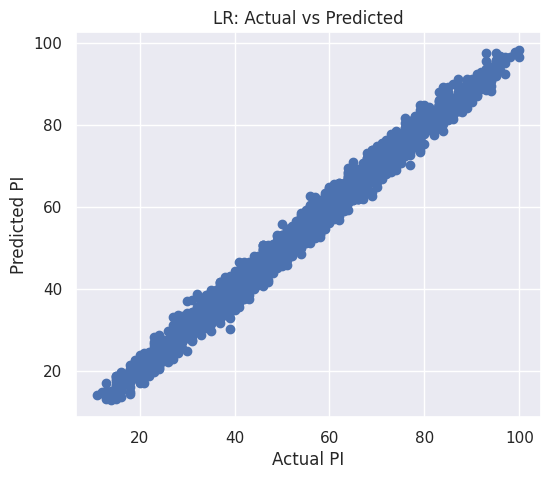

In [216]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual PI")
plt.ylabel("Predicted PI")
plt.title("LR: Actual vs Predicted")
plt.show()

# SUPPORT VECTOR MACHINE

In [217]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
import numpy as np

# Initialize SVR model (using rbf kernel by default)
# SVR can be sensitive to scaling, which has already been applied.
svr_model = SVR(kernel='rbf') # You can experiment with other kernels like 'linear', 'poly', 'sigmoid'

# Train the model and measure training time
start_time = time.time()
svr_model.fit(X_train, y_train)
end_time = time.time()
training_time_svr = end_time - start_time

# Make predictions on the test set and measure testing time
start_time = time.time()
y_pred_svr = svr_model.predict(X_test)
end_time = time.time()
testing_time_svr = end_time - start_time

# Evaluate the model
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

print(f"Support Vector Regressor MAE: {mae_svr:.2f}")
print(f"Support Vector Regressor RMSE: {rmse_svr:.2f}")
print(f"Support Vector Regressor R2 Score: {r2_svr:.2f}")
print(f"Support Vector Regressor Training Time: {training_time_svr:.4f} seconds")
print(f"Support Vector Regressor Testing Time: {testing_time_svr:.4f} seconds")


Support Vector Regressor MAE: 1.84
Support Vector Regressor RMSE: 2.32
Support Vector Regressor R2 Score: 0.99
Support Vector Regressor Training Time: 2.1798 seconds
Support Vector Regressor Testing Time: 0.8932 seconds


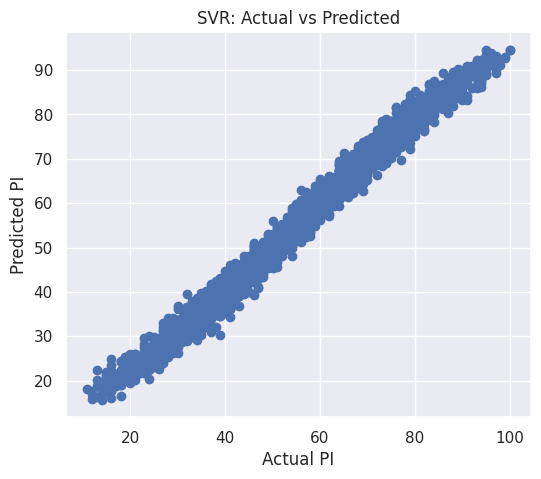

In [218]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_svr)
plt.xlabel("Actual PI")
plt.ylabel("Predicted PI")
plt.title("SVR: Actual vs Predicted")
plt.show()

# DECISION TREE REGRESSOR

In [219]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
import numpy as np

# Initialize Decision Tree Regressor model
dt_model = DecisionTreeRegressor(random_state=42) # Using random_state for reproducibility

# Train the model and measure training time
start_time = time.time()
dt_model.fit(X_train, y_train)
end_time = time.time()
training_time_dt = end_time - start_time

# Make predictions on the test set and measure testing time
start_time = time.time()
y_pred_dt = dt_model.predict(X_test)
end_time = time.time()
testing_time_dt = end_time - start_time

# Evaluate the model
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree Regressor MAE: {mae_dt:.2f}")
print(f"Decision Tree Regressor RMSE: {rmse_dt:.2f}")
print(f"Decision Tree Regressor R2 Score: {r2_dt:.2f}")
print(f"Decision Tree Regressor Training Time: {training_time_dt:.4f} seconds")
print(f"Decision Tree Regressor Testing Time: {testing_time_dt:.4f} seconds")


Decision Tree Regressor MAE: 2.42
Decision Tree Regressor RMSE: 3.04
Decision Tree Regressor R2 Score: 0.98
Decision Tree Regressor Training Time: 0.0291 seconds
Decision Tree Regressor Testing Time: 0.0024 seconds


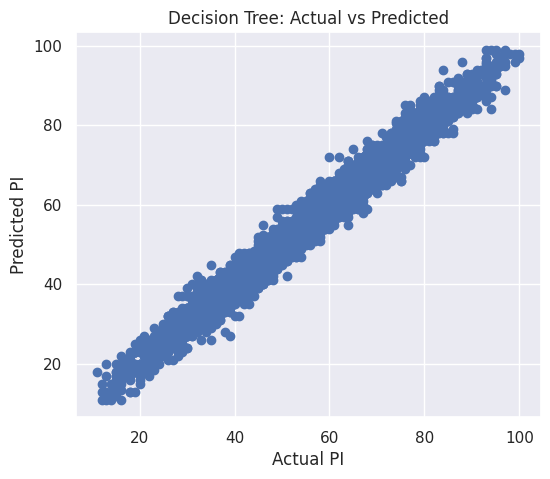

In [220]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_dt)
plt.xlabel("Actual PI")
plt.ylabel("Predicted PI")
plt.title("Decision Tree: Actual vs Predicted")
plt.show()

# RANDOM FOREST

In [221]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
import numpy as np

# Initialize Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42) # Using random_state for reproducibility

# Train the model and measure training time
start_time = time.time()
rf_model.fit(X_train, y_train)
end_time = time.time()
training_time_rf = end_time - start_time

# Make predictions on the test set and measure testing time
start_time = time.time()
y_pred_rf = rf_model.predict(X_test)
end_time = time.time()
testing_time_rf = end_time - start_time

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regressor MAE: {mae_rf:.2f}")
print(f"Random Forest Regressor RMSE: {rmse_rf:.2f}")
print(f"Random Forest Regressor R2 Score: {r2_rf:.2f}")
print(f"Random Forest Regressor Training Time: {training_time_rf:.4f} seconds")
print(f"Random Forest Regressor Testing Time: {testing_time_rf:.4f} seconds")


Random Forest Regressor MAE: 1.86
Random Forest Regressor RMSE: 2.34
Random Forest Regressor R2 Score: 0.99
Random Forest Regressor Training Time: 2.1452 seconds
Random Forest Regressor Testing Time: 0.1081 seconds


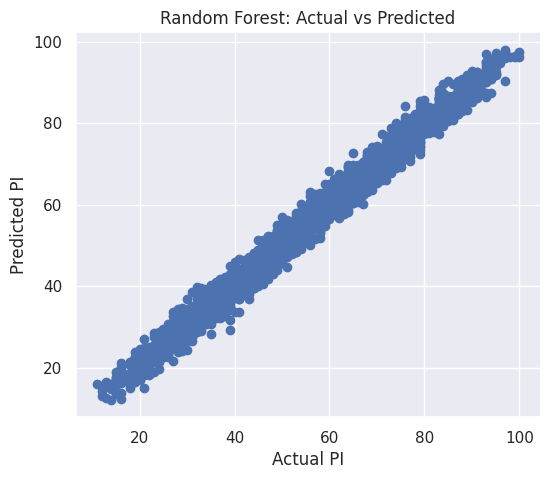

In [222]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual PI")
plt.ylabel("Predicted PI")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

# KNN

In [223]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
import numpy as np

# Initialize KNN Regressor model
knn_model = KNeighborsRegressor(n_neighbors=25)

# Train the model

start_time = time.time()
knn_model.fit(X_train, y_train)
end_time = time.time()
training_time_knn = end_time - start_time

# Make predictions on the test set

start_time = time.time()
y_pred_knn = knn_model.predict(X_test)
end_time = time.time()
testing_time_knn = end_time - start_time

# Evaluate the model
mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

print(f"KNN Regressor MAE: {mae_knn:.2f}")
print(f"KNN Regressor RMSE: {rmse_knn:.2f}")
print(f"KNN Regressor R2 Score: {r2_knn:.2f}")
print(f"KNN Regressor Training Time: {training_time_knn:.4f} seconds")
print(f"KNN Regressor Testing Time: {testing_time_knn:.4f} seconds")


KNN Regressor MAE: 3.03
KNN Regressor RMSE: 3.84
KNN Regressor R2 Score: 0.96
KNN Regressor Training Time: 0.0120 seconds
KNN Regressor Testing Time: 0.0899 seconds


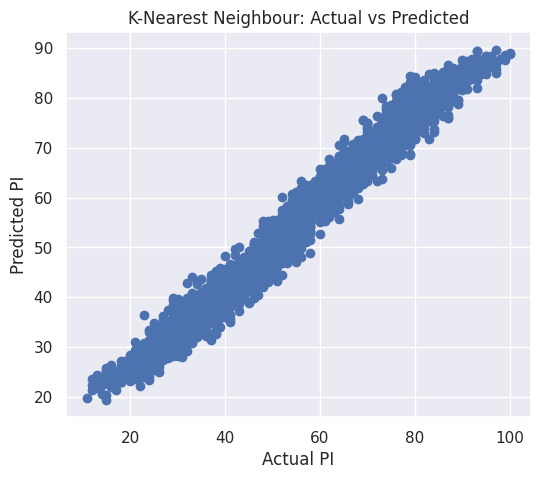

In [224]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_knn)
plt.xlabel("Actual PI")
plt.ylabel("Predicted PI")
plt.title("K-Nearest Neighbour: Actual vs Predicted")
plt.show()


### Answer the follwing
1) Explain how Random Forest Regressor predicts a continuous value.
Include:
What is a decision tree regressor?
What is bootstrapping?
How multiple trees are used?
How final output is calculated?






 A decision tree regressor is a supervised learning algorithm that works by splitting the data into subsets based on feature values. For regression, it makes predictions by averaging the target values of the training samples that fall into the same leaf node. Essentially, it learns a set of if-else rules to partition the data and then assigns a continuous value (the average) to each partition.

Bootstrapping is a resampling technique used in Random Forests. It involves creating multiple new training datasets by sampling with replacement from the original dataset. Each new dataset has the same number of samples as the original, but because of sampling with replacement, some original samples may appear multiple times, while others may not appear at all. This randomness in data selection is crucial for creating diverse individual decision trees.

In a Random Forest, instead of building a single decision tree, many decision trees (estimators) are built independently. Each tree is trained on a different bootstrapped subset of the training data. Additionally, when building each tree, only a random subset of features is considered at each split point. This dual source of randomness (bootstrapping samples and random feature subsets) ensures that the individual trees are diverse and not highly correlated with each other.

Once all the individual decision trees in the forest are trained, to predict a continuous value for a new, unseen data point, each tree independently makes its own prediction. For regression, the final output of the Random Forest is then calculated by averaging the predictions of all individual decision trees. This averaging process helps to reduce variance and improve the overall accuracy and generalization ability of the model compared to a single decision tree.

In essence, a Random Forest Regressor leverages the power of many diverse decision trees, each trained on a slightly different view of the data and features, and combines their individual predictions through averaging to produce a robust and accurate continuous output.

### Answer the following

2) Explain how KNN Regressor predicts output for a new data point.
Include:
What is K?
How neighbors are selected?
How final predicted value is calculated?

'K' in KNN stands for the number of nearest neighbors that will be considered when making a prediction. It's a hyperparameter that is chosen before training the model. A larger 'K' value means more neighbors are included in the prediction, which can smooth out the predictions and reduce the impact of noise, but might also blur the local structure of the data. A smaller 'K' makes the model more sensitive to local patterns but also more susceptible to noise.

When a new, unseen data point comes in for a prediction, the KNN Regressor calculates the distance between this new data point and all other data points in the training dataset. Common distance metrics include Euclidean distance (the most frequent choice), Manhattan distance, or others. The 'K' data points from the training set that have the smallest distances to the new data point are identified as its 'nearest neighbors'.

Once the 'K' nearest neighbors are identified, the KNN Regressor predicts the continuous output for the new data point by taking the average of the target values of those 'K' neighbors. If a weighted average is used, closer neighbors might have a greater influence on the prediction than further ones. This simple averaging mechanism allows KNN to predict a continuous value based on the values of similar, already-seen data points.

## Visualize Best Model

In [225]:
# Select best model based on R2

The best model based on the R2 score is the Linear Regression model. It has an overall score of 0.9882, the highest compared to other models.
The R2 score indicates the proportion of variance in the dependent variable that can be predicted from the independent variable. An R2 score of 0.9882 means that 98.82% of the variance in the "Performance Index" can be explained by the features used in the model.

In [226]:
results = {
    'Model': ['Linear Regression', 'SVR', 'Decision Tree', 'Random Forest', 'KNN'],
    'MAE': [mae_lr, mae_svr, mae_dt, mae_rf, mae_knn],
    'RMSE': [rmse_lr, rmse_svr, rmse_dt, rmse_rf, rmse_knn],
    'R2 Score': [r2_lr, r2_svr, r2_dt, r2_rf, r2_knn],
    'Training Time': [training_time_lr, training_time_svr, training_time_dt, training_time_rf, training_time_knn],
    'Testing Time': [testing_time_lr, testing_time_svr, testing_time_dt, testing_time_rf, testing_time_knn]
}

# Create a DataFrame from the results dictionary
df_results = pd.DataFrame(results)

# Display the DataFrame
display(df_results.round(4))


,Model,MAE,RMSE,R2 Score,Training Time,Testing Time
0,Linear Regression,1.6089,2.0220,0.9891,0.0092,0.0017
1,SVR,1.8380,2.3243,0.9856,2.1798,0.8932
2,Decision Tree,2.4156,3.0445,0.9754,0.0291,0.0024
3,Random Forest,1.8629,2.3385,0.9855,2.1452,0.1081
4,KNN,3.0254,3.8380,0.9609,0.0120,0.0899


## Generate a Comparison Table of Regression Models

Your output should look like this:

| Model | MAE | RMSE | R2 Score |Training Time|Testing Time|
|-------|-----|------|----------|-------------|------------|
| Linear Regression | | | |||
| SVR | | | |||
| Decision Tree | | | |||
| Random Forest | | | |||
| KNN | | | |||

---